In [1]:
!pip install -q transformers datasets accelerate

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer

In [2]:
dataset = [
 {"prompt":"DB timeout, connection pool exhausted","response":"increase_pool"},
 {"prompt":"Too many DB connections","response":"increase_pool"},
 {"prompt":"Slow DB query","response":"optimize_query"},
 {"prompt":"Database disk full","response":"cleanup_disk"},
 {"prompt":"Database not responding","response":"restart_db"},

 {"prompt":"User token expired","response":"refresh_tokens"},
 {"prompt":"Invalid token error","response":"fix_invalid_token"},
 {"prompt":"Auth service down","response":"restart_auth"},
 {"prompt":"Too many login requests","response":"increase_rate_limit"},

 {"prompt":"Cache miss rate high","response":"scale_cache"},
 {"prompt":"Cache returning stale data","response":"clear_cache"},
 {"prompt":"Cache server down","response":"restart_cache"},

 {"prompt":"Queue backlog increasing","response":"scale_consumers"},
 {"prompt":"Messages not processed","response":"restart_consumer"},
 {"prompt":"Message acknowledgement issue","response":"fix_ack_logic"},

 {"prompt":"Load imbalance detected","response":"fix_routing"},
 {"prompt":"Load balancer down","response":"restart_lb"},

 {"prompt":"API latency high","response":"scale_api"},
 {"prompt":"API service down","response":"restart_api"}
]

In [3]:
train_data = [{"text": f"{d['prompt']} -> {d['response']}"} for d in dataset]
train_dataset = Dataset.from_list(train_data)

print(train_dataset[0])

{'text': 'DB timeout, connection pool exhausted -> increase_pool'}


In [4]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [10]:
def tokenize(example):
    tokens = tokenizer(
        example["text"],
        truncation=True,
        padding=False,
        max_length=64
    )

    tokens["labels"] = tokens["input_ids"].copy()  # 🔥 THIS LINE FIXES EVERYTHING

    return tokens
tokenized_dataset = train_dataset.map(tokenize)

Map:   0%|          | 0/19 [00:00<?, ? examples/s]

In [11]:
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=1,
    num_train_epochs=1,
    logging_steps=1,
    save_steps=5,
    fp16=False,
    report_to="none"
)

In [12]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
)

In [13]:
trainer.train()

Step,Training Loss
1,7.864806
2,4.577752
3,6.478410
4,6.181705
5,4.041687
6,3.840636
7,4.680263
8,2.640436
9,5.616817
10,4.305943


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=19, training_loss=4.462834333118639, metrics={'train_runtime': 806.0494, 'train_samples_per_second': 0.024, 'train_steps_per_second': 0.024, 'total_flos': 270570972672.0, 'train_loss': 4.462834333118639, 'epoch': 1.0})

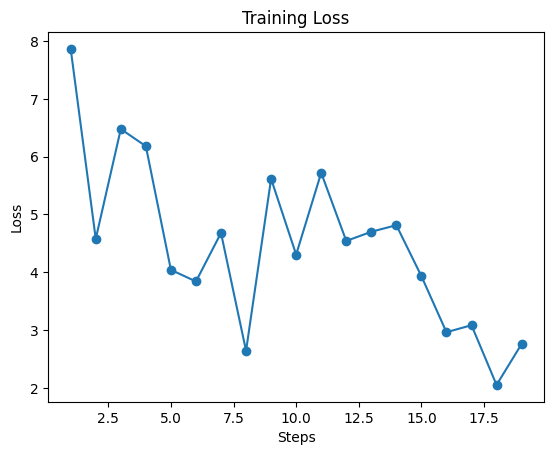

In [14]:
logs = trainer.state.log_history

import matplotlib.pyplot as plt
steps = [x["step"] for x in logs if "loss" in x]
loss  = [x["loss"] for x in logs if "loss" in x]

plt.plot(steps, loss, marker='o')
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [15]:
model.save_pretrained("debug-model")
tokenizer.save_pretrained("debug-model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('debug-model/tokenizer_config.json',
 'debug-model/chat_template.jinja',
 'debug-model/tokenizer.json')